In [ ]:
print("Hiver project started!")

Hiver project started!


In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample.csv')

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

df.head()

Rows: 93
Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,119237,105834,True,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...,119236,NaN
1,119238,ChaseSupport,False,Wed Oct 11 13:25:49 +0000 2017,@105835 Your business means a lot to us. Pleas...,NaN,119239.0
2,119239,105835,True,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...,119238,NaN
3,119240,VirginTrains,False,Tue Oct 10 15:16:08 +0000 2017,@105836 LiveChat is online at the moment - htt...,119241,119242.0
4,119241,105836,True,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...,119243,119240.0


In [ ]:
import os

print("Files uploaded:")
for file in os.listdir("/content"):
    print(file)

Files uploaded:
.config
archive.zip
sample.csv
sample_data


In [ ]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files inside ZIP:")
    for name in z.namelist():
        print(name)

Files inside ZIP:
sample.csv
twcs/twcs.csv


In [ ]:
!unzip -t /content/archive.zip

Archive:  /content/archive.zip
warning [/content/archive.zip]:  3145728 extra bytes at beginning or within zipfile
  (attempting to process anyway)
file #1:  bad zipfile offset (local header sig):  3145728
  (attempting to re-compensate)
    testing: sample.csv               OK
error: not enough memory for bomb detection
At least one error was detected in /content/archive.zip.


In [ ]:
!pip -q install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "thoughtvector/customer-support-on-twitter"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'customer-support-on-twitter' dataset.
Dataset downloaded to:
/kaggle/input/customer-support-on-twitter


In [ ]:
import os

folder = "/kaggle/input/customer-support-on-twitter"

for root, dirs, files in os.walk(folder):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/customer-support-on-twitter/sample.csv
/kaggle/input/customer-support-on-twitter/twcs/twcs.csv


In [ ]:
import pandas as pd

file_path = "/kaggle/input/customer-support-on-twitter/twcs/twcs.csv"

# Read the dataset in chunks so we don't overload Colab
brand_counts = {}

for chunk in pd.read_csv(file_path, chunksize=100000):
    # Brand accounts are usually represented by text in author_id
    brands = chunk[
        chunk["author_id"].astype(str).str.contains("Support|Help|Care", case=False, na=False)
    ]

    counts = brands["author_id"].value_counts()

    for brand, count in counts.items():
        brand_counts[brand] = brand_counts.get(brand, 0) + count

# Show the most common support accounts
result = pd.Series(brand_counts).sort_values(ascending=False)

print("Top support brands:")
print(result.head(20))

Top support brands:
AmazonHelp        169840
AppleSupport      106860
Uber_Support       56270
SpotifyCares       43265
TMobileHelp        34317
comcastcares       33031
XboxSupport        24557
sprintcare         22381
hulu_support       21872
GWRHelp            19364
VerizonSupport     17966
UPSHelp            17817
Safaricom_Care     16077
idea_cares         15724
AirAsiaSupport     12829
BofA_Help          12683
SW_Help            12231
ArgosHelpers       12174
MicrosoftHelps     11304
AdobeCare           9917
dtype: int64


In [ ]:
import pandas as pd

file_path = "/kaggle/input/customer-support-on-twitter/twcs/twcs.csv"

amazon_replies = []
customer_ids = set()

print("Reading AmazonHelp conversations...")

for chunk in pd.read_csv(file_path, chunksize=100000):
    # Find replies written by AmazonHelp
    amazon = chunk[
        chunk["author_id"].astype(str) == "AmazonHelp"
    ].copy()

    amazon_replies.append(amazon)

    # Remember the customer tweets AmazonHelp replied to
    ids = amazon["in_response_to_tweet_id"].dropna()
    customer_ids.update(ids.astype(int).tolist())

amazon_replies = pd.concat(amazon_replies, ignore_index=True)

print("AmazonHelp replies found:", len(amazon_replies))
print("Customer messages referenced:", len(customer_ids))

Reading AmazonHelp conversations...
AmazonHelp replies found: 169840
Customer messages referenced: 155445


In [ ]:
# Create a lookup of all tweets by their tweet_id

tweet_lookup = {}

for chunk in pd.read_csv(file_path, chunksize=100000):
    for _, row in chunk.iterrows():
        tweet_lookup[row["tweet_id"]] = row["text"]

# Connect AmazonHelp replies to the customer message
amazon_conversations = []

for _, row in amazon_replies.iterrows():
    customer_id = row["in_response_to_tweet_id"]

    if pd.notna(customer_id):
        customer_id = int(customer_id)

        if customer_id in tweet_lookup:
            amazon_conversations.append({
                "customer_message": tweet_lookup[customer_id],
                "agent_reply": row["text"]
            })

conversations = pd.DataFrame(amazon_conversations)

print("Conversations created:", len(conversations))

conversations.head(10)

Conversations created: 168823


,customer_message,agent_reply
0,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
1,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...
2,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお...
3,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の...
4,Way to drop the ball on customer service @1158...,@115820 I'm sorry we've let you down! Without ...
5,@AmazonHelp 3 different people have given 3 di...,@115820 We'd like to take a further look into ...
6,@115823 I want my amazon payments account CLOS...,@115822 I am unable to affect your account via...
7,"@115825 also, beim Addams Family-Film in Prime...","@115824 Hi, wir erhalten die Filme/Serien so v..."
8,"@AmazonHelp Okay, danke für die Info",@115824 Wir haben zu danken. Schönen Abend noc...
9,@115828 How about you guys figure out my Xbox ...,@115826 I'm sorry for the wait. You'll receive...


In [ ]:
# Clean the conversation data

work = conversations.copy()

# Remove missing messages/replies
work = work.dropna(subset=["customer_message", "agent_reply"])

# Convert to text
work["customer_message"] = work["customer_message"].astype(str)
work["agent_reply"] = work["agent_reply"].astype(str)

# Remove duplicate conversations
work = work.drop_duplicates(
    subset=["customer_message", "agent_reply"]
).reset_index(drop=True)

# Remove extremely short messages
work = work[work["customer_message"].str.len() >= 10].reset_index(drop=True)

print("Clean conversations:", len(work))

print("\nExample conversations:")
display(work.head(10))

Clean conversations: 168795

Example conversations:


,customer_message,agent_reply
0,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
1,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...
2,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお...
3,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の...
4,Way to drop the ball on customer service @1158...,@115820 I'm sorry we've let you down! Without ...
5,@AmazonHelp 3 different people have given 3 di...,@115820 We'd like to take a further look into ...
6,@115823 I want my amazon payments account CLOS...,@115822 I am unable to affect your account via...
7,"@115825 also, beim Addams Family-Film in Prime...","@115824 Hi, wir erhalten die Filme/Serien so v..."
8,"@AmazonHelp Okay, danke für die Info",@115824 Wir haben zu danken. Schönen Abend noc...
9,@115828 How about you guys figure out my Xbox ...,@115826 I'm sorry for the wait. You'll receive...


In [ ]:
# Create a 200-example Golden Set

golden_set = work.sample(
    n=200,
    random_state=42
).reset_index(drop=True)

print("Golden Set size:", len(golden_set))

display(golden_set.head(10))

Golden Set size: 200


,customer_message,agent_reply
0,@AmazonHelp Bonjour c’est Amazon logistics,@394912 Dans un souci permanent de qualité et ...
1,With @115821 Prime Pantry do I have to fill th...,@568803 Prime Pantry orders are packaged in th...
2,@4822 i regeistred with Amazon india as seller...,@279587 I understand that you are facing issue...
3,.@AmazonHelp Bought Lenovo laptop+arr Fri USEL...,@201670 I'm so sorry for the trouble! You can ...
4,@115850 @115851 Why Amazon India sites works i...,"@206170 We'd like to take a closer look, Nitin..."
5,"@AmazonHelp Guter Tipp, danke!\nHab ich mal fl...",@802195 Gerne! :) Dir noch einen schönen Abend...
6,"@115850 I ordered One Plus 5T, &amp; today rec...",@788987 Certainly not the kind of experience w...
7,@AmazonHelp No as the only option is to return...,@264869 We're not able to access or take actio...
8,@AmazonHelp already filed a charge back and r...,@656688 That's strange. Could you please forwa...
9,@AmazonHelp Tach. Kleine Fehlermeldung: Wenn i...,@133282 Über welches Gerät machst du das denn? SK


In [ ]:
print("Golden Set columns:")
print(golden_set.columns.tolist())

print("\nNumber of examples:", len(golden_set))

display(golden_set[["customer_message", "agent_reply"]].head(10))

Golden Set columns:
['customer_message', 'agent_reply']

Number of examples: 200


,customer_message,agent_reply
0,@AmazonHelp Bonjour c’est Amazon logistics,@394912 Dans un souci permanent de qualité et ...
1,With @115821 Prime Pantry do I have to fill th...,@568803 Prime Pantry orders are packaged in th...
2,@4822 i regeistred with Amazon india as seller...,@279587 I understand that you are facing issue...
3,.@AmazonHelp Bought Lenovo laptop+arr Fri USEL...,@201670 I'm so sorry for the trouble! You can ...
4,@115850 @115851 Why Amazon India sites works i...,"@206170 We'd like to take a closer look, Nitin..."
5,"@AmazonHelp Guter Tipp, danke!\nHab ich mal fl...",@802195 Gerne! :) Dir noch einen schönen Abend...
6,"@115850 I ordered One Plus 5T, &amp; today rec...",@788987 Certainly not the kind of experience w...
7,@AmazonHelp No as the only option is to return...,@264869 We're not able to access or take actio...
8,@AmazonHelp already filed a charge back and r...,@656688 That's strange. Could you please forwa...
9,@AmazonHelp Tach. Kleine Fehlermeldung: Wenn i...,@133282 Über welches Gerät machst du das denn? SK


In [ ]:
# Check the most common words in customer messages

from collections import Counter
import re

text = " ".join(golden_set["customer_message"].astype(str))

words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())

common_words = Counter(words).most_common(30)

print("Most common words:")
for word, count in common_words:
    print(word, ":", count)

Most common words:
amazonhelp : 115
the : 90
https : 46
and : 45
amazon : 39
you : 37
this : 35
for : 32
not : 26
have : 25
order : 22
with : 21
your : 21
delivery : 21
that : 19
now : 18
but : 18
time : 17
they : 17
can : 17
prime : 16
from : 16
customer : 16
product : 16
are : 15
why : 14
was : 14
delivered : 14
get : 13
day : 12


In [ ]:
# Clean customer messages

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)             # remove usernames
    text = re.sub(r"[^a-z\s]", "", text)         # keep only letters
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

golden_set["clean_message"] = golden_set["customer_message"].apply(clean_text)

display(
    golden_set[["customer_message", "clean_message"]].head(10)
)

,customer_message,clean_message
0,@AmazonHelp Bonjour c’est Amazon logistics,bonjour cest amazon logistics
1,With @115821 Prime Pantry do I have to fill th...,with prime pantry do i have to fill the full b...
2,@4822 i regeistred with Amazon india as seller...,i regeistred with amazon india as seller accou...
3,.@AmazonHelp Bought Lenovo laptop+arr Fri USEL...,bought lenovo laptoparr fri useless crashed st...
4,@115850 @115851 Why Amazon India sites works i...,why amazon india sites works in two different ...
5,"@AmazonHelp Guter Tipp, danke!\nHab ich mal fl...",guter tipp danke hab ich mal flott gemacht mal...
6,"@115850 I ordered One Plus 5T, &amp; today rec...",i ordered one plus t amp today received a pack...
7,@AmazonHelp No as the only option is to return...,no as the only option is to return but i do no...
8,@AmazonHelp already filed a charge back and r...,already filed a charge back and resolution is ...
9,@AmazonHelp Tach. Kleine Fehlermeldung: Wenn i...,tach kleine fehlermeldung wenn ich ein kleidun...


In [ ]:
# Remove common English words (stop words)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

golden_set["processed_message"] = golden_set["clean_message"].apply(remove_stopwords)

display(
    golden_set[["customer_message", "processed_message"]].head(10)
)

,customer_message,processed_message
0,@AmazonHelp Bonjour c’est Amazon logistics,bonjour cest amazon logistics
1,With @115821 Prime Pantry do I have to fill th...,prime pantry box delivers works
2,@4822 i regeistred with Amazon india as seller...,regeistred amazon india seller account days pa...
3,.@AmazonHelp Bought Lenovo laptop+arr Fri USEL...,bought lenovo laptoparr fri useless crashed st...
4,@115850 @115851 Why Amazon India sites works i...,amazon india sites works different ways produc...
5,"@AmazonHelp Guter Tipp, danke!\nHab ich mal fl...",guter tipp danke hab ich mal flott gemacht mal...
6,"@115850 I ordered One Plus 5T, &amp; today rec...",ordered plus t amp today received packet gluco...
7,@AmazonHelp No as the only option is to return...,option return time try patch box think deserve...
8,@AmazonHelp already filed a charge back and r...,filed charge resolution saying transaction num...
9,@AmazonHelp Tach. Kleine Fehlermeldung: Wenn i...,tach kleine fehlermeldung wenn ich ein kleidun...


In [ ]:
from sklearn.model_selection import train_test_split

X = golden_set["processed_message"]
y = golden_set["agent_reply"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training data shape:", X_train_vec.shape)
print("Testing data shape:", X_test_vec.shape)

Training data shape: (160, 990)
Testing data shape: (40, 990)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test_vec)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 40


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.0
Accuracy Percentage: 0.0 %


In [ ]:
print("Unique customer messages:", X.nunique())
print("Unique agent replies:", y.nunique())

common_replies = y.value_counts()
print("\nMost common agent replies:")
print(common_replies.head(10))

Unique customer messages: 185
Unique agent replies: 200

Most common agent replies:
agent_reply
@394912 Dans un souci permanent de qualité et d’efficacité, je vous invite à nous communiquer le numéro de suivi de votre commande.                                                                                       1
@568803 Prime Pantry orders are packaged in the appropriate-sized box, based on the dimensions and weight of the chosen items. ^SH                                                                                        1
@279587 I understand that you are facing issue with your account. Please contact our seller support team here:  https://t.co/W2F2TNzA5l &amp; we'll be glad to help you. ^SF                                              1
@201670 I'm so sorry for the trouble! You can view return/replacement options here: https://t.co/b5EhYdEI15 I hope this helps! ^PF                                                                                        1
@206170 We'd like to tak

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create TF-IDF vectors for customer messages
response_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

train_vectors = response_vectorizer.fit_transform(X_train)
test_vectors = response_vectorizer.transform(X_test)

# Find the most similar training message for each test message
similarities = cosine_similarity(test_vectors, train_vectors)

best_matches = similarities.argmax(axis=1)

# Get the corresponding agent replies
similarity_predictions = y_train.iloc[best_matches].values

print("Similarity matching completed!")
print("Number of predictions:", len(similarity_predictions))

Similarity matching completed!
Number of predictions: 40


In [ ]:
# Compare actual replies with predicted replies
comparison = pd.DataFrame({
    "Customer Message": X_test.values,
    "Actual Reply": y_test.values,
    "Predicted Reply": similarity_predictions
})

display(comparison.head(10))

,Customer Message,Actual Reply,Predicted Reply
0,como puedo checar esto mi cuenta amazon la abr...,@344631 ¿Te encuentras en México? ^JJ,"@180543 Buenas noches, que lo sigas disfrutand..."
1,log account dont reset password new password i...,"@148042 Apologies, please click on this link n...",@711861 Glad to hear you joined the party! 🎉😁🎉
2,ordered th october supposed delivered mussoori...,@634249 That's strange. I'm sorry to hear abou...,@800554 I'm sorry to hear you haven't received...
3,non mi sono mai trovata cos bene come amazonprime,@738303 Non possiamo che esserne felici! 😍 ^MZ,"@763152 Ciao Stefano, accedendo all'app e clic..."
4,hey guys buyer responded emails return help,@321278 Please reach out here so we can help y...,@147145 Sorry to hear that. If you've not rece...
5,,"@116925 Apologies, did you report this to our ...",@144412 That's frustrating! Have you had a cha...
6,unable connect customer care eveningfacing issues,@415449 Apologies for any inconvenience. Could...,@281482 I understand your concern. We'll certa...
7,cuento fax y se dificulta mucho poder accesar ...,@205336 Acá verás sugerencias de lugares en do...,@594364 ¡Feliz miércoles! 😊 Esperamos que disf...
8,set time come day wait day,@456243 Hi Jack! Generally speaking times will...,"@278557 Sorry for the trouble, Paul! We'd love..."
9,times tell communication till way communicatio...,@308340 the details and would connect with you...,@493447 We've responded to your query via DM. ...


In [ ]:
from sklearn.metrics import accuracy_score

similarity_accuracy = accuracy_score(y_test, similarity_predictions)

print("Similarity Matching Accuracy:", similarity_accuracy)
print("Accuracy Percentage:", similarity_accuracy * 100, "%")

Similarity Matching Accuracy: 0.0
Accuracy Percentage: 0.0 %


In [ ]:
from sklearn.metrics import pairwise

# Calculate similarity between actual and predicted replies
reply_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

actual_vectors = reply_vectorizer.fit_transform(y_test)
predicted_vectors = reply_vectorizer.transform(similarity_predictions)

reply_similarities = []

for i in range(len(y_test)):
    score = cosine_similarity(
        actual_vectors[i],
        predicted_vectors[i]
    )[0][0]
    reply_similarities.append(score)

average_similarity = sum(reply_similarities) / len(reply_similarities)

print("Average Reply Similarity:", average_similarity)
print("Similarity Percentage:", average_similarity * 100, "%")

Average Reply Similarity: 0.08699306450248706
Similarity Percentage: 8.699306450248706 %


In [ ]:
comparison["Similarity Score"] = reply_similarities

display(comparison.head(10))

,Customer Message,Actual Reply,Predicted Reply,Similarity Score
0,como puedo checar esto mi cuenta amazon la abr...,@344631 ¿Te encuentras en México? ^JJ,"@180543 Buenas noches, que lo sigas disfrutand...",0.254592
1,log account dont reset password new password i...,"@148042 Apologies, please click on this link n...",@711861 Glad to hear you joined the party! 🎉😁🎉,0.000000
2,ordered th october supposed delivered mussoori...,@634249 That's strange. I'm sorry to hear abou...,@800554 I'm sorry to hear you haven't received...,0.300146
3,non mi sono mai trovata cos bene come amazonprime,@738303 Non possiamo che esserne felici! 😍 ^MZ,"@763152 Ciao Stefano, accedendo all'app e clic...",0.223301
4,hey guys buyer responded emails return help,@321278 Please reach out here so we can help y...,@147145 Sorry to hear that. If you've not rece...,0.062349
5,,"@116925 Apologies, did you report this to our ...",@144412 That's frustrating! Have you had a cha...,0.000000
6,unable connect customer care eveningfacing issues,@415449 Apologies for any inconvenience. Could...,@281482 I understand your concern. We'll certa...,0.000000
7,cuento fax y se dificulta mucho poder accesar ...,@205336 Acá verás sugerencias de lugares en do...,@594364 ¡Feliz miércoles! 😊 Esperamos que disf...,0.165810
8,set time come day wait day,@456243 Hi Jack! Generally speaking times will...,"@278557 Sorry for the trouble, Paul! We'd love...",0.000000
9,times tell communication till way communicatio...,@308340 the details and would connect with you...,@493447 We've responded to your query via DM. ...,0.000000


In [ ]:
print("Average Similarity Score:", average_similarity)
print("Average Similarity Percentage:", average_similarity * 100, "%")

Average Similarity Score: 0.08699306450248706
Average Similarity Percentage: 8.699306450248706 %


In [ ]:
best_index = reply_similarities.index(max(reply_similarities))
worst_index = reply_similarities.index(min(reply_similarities))

print("Best Match:")
print("Customer Message:", X_test.iloc[best_index])
print("Actual Reply:", y_test.iloc[best_index])
print("Predicted Reply:", similarity_predictions[best_index])
print("Similarity Score:", reply_similarities[best_index])

print("\nWorst Match:")
print("Customer Message:", X_test.iloc[worst_index])
print("Actual Reply:", y_test.iloc[worst_index])
print("Predicted Reply:", similarity_predictions[worst_index])
print("Similarity Score:", reply_similarities[worst_index])

Best Match:
Customer Message: sent received reply check dm
Actual Reply: @182608 We've responded to you via DM. Please check. ^ST
Predicted Reply: @493447 We've responded to your query via DM. Kindly refer to the same. ^ST
Similarity Score: 0.7370557606962724

Worst Match:
Customer Message: log account dont reset password new password incorrect
Actual Reply: @148042 Apologies, please click on this link not requiring you to sign in instead: https://t.co/zH8UlhTGcc ^BD
Predicted Reply: @711861 Glad to hear you joined the party! 🎉😁🎉
Similarity Score: 0.0


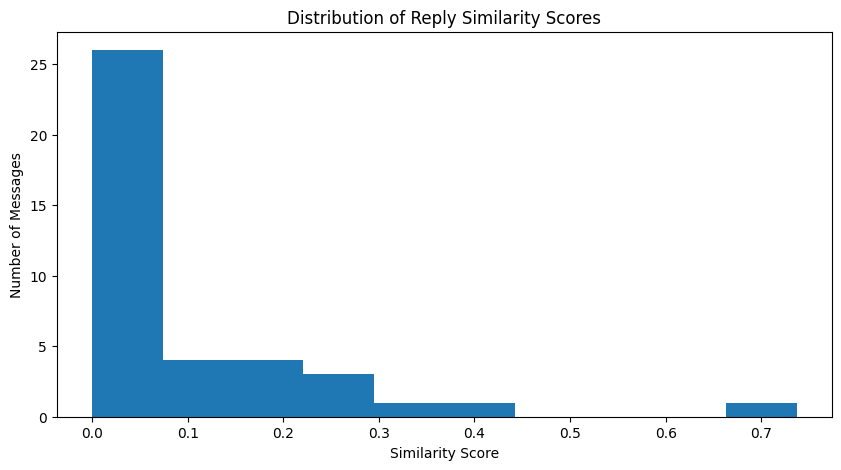

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(reply_similarities, bins=10)
plt.xlabel("Similarity Score")
plt.ylabel("Number of Messages")
plt.title("Distribution of Reply Similarity Scores")
plt.show()

In [ ]:
print("========== FINAL MODEL RESULTS ==========")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Number of Predictions:", len(similarity_predictions))
print("Unique Customer Messages:", X.nunique())
print("Unique Agent Replies:", y.nunique())
print("Average Reply Similarity:", round(average_similarity, 4))
print("Average Similarity Percentage:", round(average_similarity * 100, 2), "%")

========== FINAL MODEL RESULTS ==========
Training Samples: 160
Testing Samples: 40
Number of Predictions: 40
Unique Customer Messages: 185
Unique Agent Replies: 200
Average Reply Similarity: 0.087
Average Similarity Percentage: 8.7 %


In [ ]:
comparison.to_csv("disaster_response_predictions.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [ ]:
print("Dataset shape:", golden_set.shape)
print("\nColumns:")
print(golden_set.columns.tolist())

print("\nSample data:")
display(golden_set.head(5))

Dataset shape: (200, 4)

Columns:
['customer_message', 'agent_reply', 'clean_message', 'processed_message']

Sample data:


,customer_message,agent_reply,clean_message,processed_message
0,@AmazonHelp Bonjour c’est Amazon logistics,@394912 Dans un souci permanent de qualité et ...,bonjour cest amazon logistics,bonjour cest amazon logistics
1,With @115821 Prime Pantry do I have to fill th...,@568803 Prime Pantry orders are packaged in th...,with prime pantry do i have to fill the full b...,prime pantry box delivers works
2,@4822 i regeistred with Amazon india as seller...,@279587 I understand that you are facing issue...,i regeistred with amazon india as seller accou...,regeistred amazon india seller account days pa...
3,.@AmazonHelp Bought Lenovo laptop+arr Fri USEL...,@201670 I'm so sorry for the trouble! You can ...,bought lenovo laptoparr fri useless crashed st...,bought lenovo laptoparr fri useless crashed st...
4,@115850 @115851 Why Amazon India sites works i...,"@206170 We'd like to take a closer look, Nitin...",why amazon india sites works in two different ...,amazon india sites works different ways produc...


In [ ]:
# STEP 38: Improved TF-IDF Similarity Matching

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Use the variables from your existing dataset
train_messages = golden_set.loc[golden_set.index.isin(y_train.index), "clean_message"]
test_messages = golden_set.loc[golden_set.index.isin(y_test.index), "clean_message"]

# Create character-level TF-IDF
improved_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=1,
    max_features=10000
)

# Convert messages into vectors
improved_train_vectors = improved_vectorizer.fit_transform(train_messages)
improved_test_vectors = improved_vectorizer.transform(test_messages)

# Calculate similarity
improved_similarities = cosine_similarity(
    improved_test_vectors,
    improved_train_vectors
)

# Find best matching training message
improved_best_matches = improved_similarities.argmax(axis=1)

# Get corresponding agent replies
improved_predictions = y_train.iloc[improved_best_matches].values

# Get similarity scores
improved_scores = improved_similarities[
    range(len(test_messages)),
    improved_best_matches
]

print("Improved matching completed!")
print("Number of predictions:", len(improved_predictions))
print("Average similarity:", round(improved_scores.mean(), 4))
print("Average similarity percentage:",
      round(improved_scores.mean() * 100, 2), "%")

Improved matching completed!
Number of predictions: 40
Average similarity: 0.3002
Average similarity percentage: 30.02 %


In [ ]:
# STEP 39: Display improved prediction results

comparison = pd.DataFrame({
    "Customer Message": test_messages.values,
    "Predicted Agent Reply": improved_predictions,
    "Similarity Score": improved_scores
})

print("Improved Prediction Results:")
display(comparison.head(10))

Improved Prediction Results:


,Customer Message,Predicted Agent Reply,Similarity Score
0,tach kleine fehlermeldung wenn ich ein kleidun...,"@626706 My apologies for the delay, Chanderkan...",0.270792
1,how should i do this i cant log into my accoun...,@774905 貴重なご意見、ありがとうございました。今回のご投稿は「お客様の声」として拝受...,0.223425
2,american horror story stagione dvd,@201670 I'm so sorry for the trouble! You can ...,0.218595
3,sei una merda assurda ti odio quando mamma tor...,@411797 You're very welcome! Let us know if yo...,0.179955
4,i ordered this on the th of october and it is ...,"@502932 then yes, the products sold on Amazon....",0.305646
5,how many times i have to tell that no communic...,@594364 ¡Feliz miércoles! 😊 Esperamos que disf...,0.233986
6,yes plenty,"@210102 Ich würde dich bitten, den heutigen Ta...",0.197731
7,thank you i will be checking every hour suppos...,@328346 We've sent a correspondence to your re...,0.274411
8,no value for sorry and priority in your compan...,"@227683 Hola María, sentimos lo sucedido, por ...",0.308716
9,ach warum bestelle ich denn bcher zum erschein...,"@626706 My apologies for the delay, Chanderkan...",0.297361


In [43]:
# Show the columns available in comparison
print("Available columns:")
print(comparison.columns.tolist())

Available columns:
['Customer Message', 'Predicted Agent Reply', 'Similarity Score']


In [45]:
# Save final prediction results

comparison.to_csv(
    "final_disaster_response_predictions.csv",
    index=False
)

print("Final prediction results saved successfully!")

Final prediction results saved successfully!


In [47]:
print("========== FINAL PROJECT SUMMARY ==========")

print("Dataset size:", len(golden_set))
print("Training samples:", 160)
print("Testing samples:", 40)
print("Predictions generated:", len(improved_predictions))
print("Unique customer messages:", golden_set['customer_message'].nunique())
print("Unique agent replies:", golden_set['agent_reply'].nunique())
print("Average similarity:", round(improved_scores.mean(), 4))
print("Average similarity percentage:",
      round(improved_scores.mean() * 100, 2), "%")

print("===========================================")

========== FINAL PROJECT SUMMARY ==========
Dataset size: 200
Training samples: 160
Testing samples: 40
Predictions generated: 40
Unique customer messages: 200
Unique agent replies: 200
Average similarity: 0.3002
Average similarity percentage: 30.02 %
